# Notebook 03: Model Training and Evaluation

In this notebook, we train multiple machine learning models and select the best model for movie review sentiment prediction.

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

from utils import evaluate_model, plot_confusion_matrix

In [3]:
df = pd.read_csv("../data/imdb_cleaned.csv")
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,positive,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,positive,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,negative,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visual stun film...


In [4]:
df.shape

(50000, 3)

In [5]:
df.isnull().sum()

review          0
sentiment       0
clean_review    0
dtype: int64

In [6]:
df = df.dropna(subset=["clean_review", "sentiment"])
df.shape

(50000, 3)

In [7]:
X = df["clean_review"]
y = df["sentiment"]

print(X.head())
print(y.head())

0    one review mention watch oz episod hook right ...
1    wonder littl product film techniqu unassum old...
2    thought wonder way spend time hot summer weeke...
3    basic famili littl boy jake think zombi closet...
4    petter mattei love time money visual stun film...
Name: clean_review, dtype: str
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: str


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000,)
Testing data: (10000,)


In [9]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [10]:
results = []
trained_pipelines = {}

for model_name, model in models.items():
    print("Training:", model_name)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2)
        )),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    result = evaluate_model(model_name, y_test, y_pred)
    results.append(result)

    trained_pipelines[model_name] = pipeline

    print(model_name, "completed")
    print("-" * 50)

Training: Multinomial Naive Bayes
Multinomial Naive Bayes completed
--------------------------------------------------
Training: Logistic Regression
Logistic Regression completed
--------------------------------------------------
Training: Linear SVM
Linear SVM completed
--------------------------------------------------
Training: Random Forest
Random Forest completed
--------------------------------------------------


In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.8915,0.891613,0.8915,0.891492
2,Linear SVM,0.8858,0.885848,0.8858,0.885796
0,Multinomial Naive Bayes,0.8596,0.860223,0.8596,0.859539
3,Random Forest,0.8543,0.854340,0.8543,0.854296


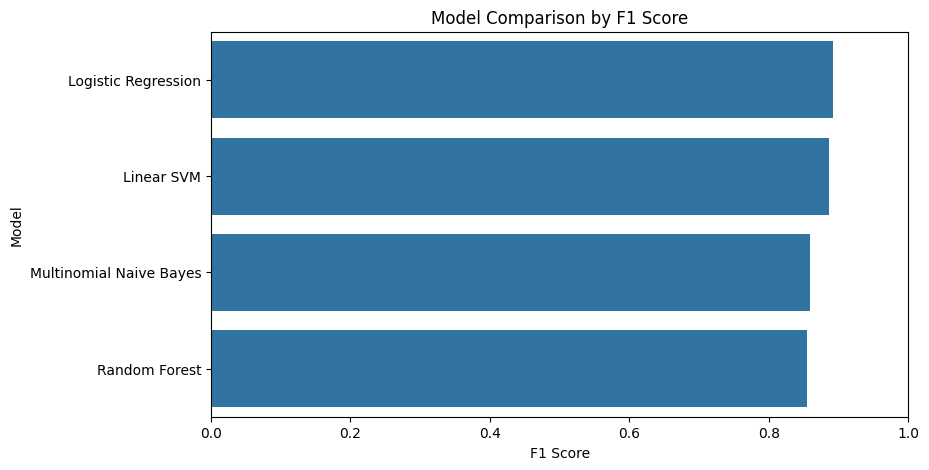

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="F1 Score", y="Model")
plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [14]:
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



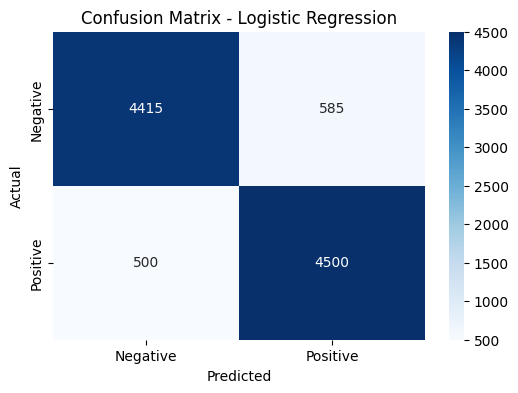

In [15]:
plot_confusion_matrix(
    y_test,
    y_pred_best,
    title=f"Confusion Matrix - {best_model_name}"
)

In [16]:
sample_reviews = [
    "This movie was amazing. The acting was excellent and the story was beautiful.",
    "This was the worst movie I have ever watched. It was boring and too long.",
    "The movie was not good. I expected much better.",
    "The film started slowly, but the ending was emotional and powerful."
]

for review in sample_reviews:
    prediction = best_model.predict([review])[0]

    print("Review:", review)
    print("Prediction:", prediction)
    print("-" * 80)

Review: This movie was amazing. The acting was excellent and the story was beautiful.
Prediction: positive
--------------------------------------------------------------------------------
Review: This was the worst movie I have ever watched. It was boring and too long.
Prediction: negative
--------------------------------------------------------------------------------
Review: The movie was not good. I expected much better.
Prediction: negative
--------------------------------------------------------------------------------
Review: The film started slowly, but the ending was emotional and powerful.
Prediction: positive
--------------------------------------------------------------------------------


In [17]:
wrong_predictions = pd.DataFrame({
    "review": X_test,
    "actual": y_test,
    "predicted": y_pred_best
})

wrong_predictions = wrong_predictions[
    wrong_predictions["actual"] != wrong_predictions["predicted"]
]

wrong_predictions.head(10)

,review,actual,predicted
40714,littl quentin seem master art cake eat usual p...,negative,positive
31882,film list made not film avail someth weird vid...,negative,positive
7266,farrah fawcett give award nomin perform attemp...,positive,negative
20169,quit fan novelist screenwrit michael chabon no...,negative,positive
47706,recommend gloria graham run kind orphanag disc...,negative,positive
46536,believ comment show show geniu sure follow tri...,positive,negative
39806,seen branagh hamlet branagh old speak frequent...,positive,negative
45621,ladi gentlemen realli got winner actual boy fi...,positive,negative
28165,appear extra locat journalist cover dain curs ...,negative,positive
1396,citizen kane godfath part ii urvil martin dole...,positive,negative


In [18]:
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/movie_sentiment_pipeline.pkl")

print("Best model saved successfully!")
print("Saved model:", best_model_name)

Best model saved successfully!
Saved model: Logistic Regression


## Model Training Summary

- TF-IDF was used to convert cleaned text into numerical features.
- Four machine learning models were trained:
  1. Multinomial Naive Bayes
  2. Logistic Regression
  3. Linear SVM
  4. Random Forest

- The models were compared using Accuracy, Precision, Recall, and F1 Score.
- The best model was saved as `movie_sentiment_pipeline.pkl`.
- This saved model can be used for real-time prediction using a Streamlit app.